# Constrained K-ALS on the seven-molecule TomoTwin tomogram

This notebook tests whether a **single shared spectral extraction stage** can
recover several anonymous particle spectra when every spectral patch is
constrained to contain at most one active component:

\[
R_j(\omega) \approx v(\omega) + a_j\gamma_{z_j}(\omega),\qquad
z_j\in\{\mathrm{background},1,\ldots,K\},\quad a_j\ge 0.
\]

The experiment uses \(K=7\), a common \(33^3\) spectral patch, and ACF support
`max_distance=16`. It performs the same two-pass workflow as the picker:

1. fit constrained K-ALS on the bandpassed tomogram;
2. prewhiten with the recovered shared noise PSD;
3. refit constrained K-ALS on the whitened tomogram;
4. solve the radial Fredholm equations independently for each recovered
   component and build its KLT templates.

The components are anonymous. Ground truth is **not** used in either K-ALS
fit. It is used only afterward to create an oracle component-to-class mapping
for this simulation diagnostic.

Two evaluations use the same recovered spectra and mapping:

- **Oracle geometry:** component \(k\) gets the mapped molecule's TomoTwin
  evaluation-box diameter.
- **Shared geometry:** every component uses the common diameter \(D=33\).

For both evaluations, the number of retained peaks equals the known number of
supported instances of the evaluated class. Matching always uses the true
class tolerance \(D_\mathrm{class}/2\), including in the shared-diameter
branch. Thus this is a controlled known-count feasibility experiment, not yet
a fully unsupervised deployment protocol.

In [1]:
from __future__ import annotations

import os
import time
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from skimage.filters import window

from kltpicker_3d.fredholm_solver import solve_radial_fredholm_equation
from kltpicker_3d.tomogram import KLTParticleDetector3D
from kltpicker_3d.utils import (
    bandpass_filter_3d,
    generate_uniform_radial_sampling_points,
    prewhiten_tomogram,
    radial_psd_to_variance,
    ranked_local_maxima_nms_3d,
    trigonometric_interpolation,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

print("JAX:", jax.__version__)
print("JAX devices:", jax.devices())

JAX: 0.10.2
JAX devices: [CpuDevice(id=0)]


## Configuration and TomoTwin metadata

In [2]:
DATA_DIR = Path("data/tomotwin_2df7")
TOMOGRAM_PATH = DATA_DIR / "tiltseries_rec.mrc"
POSITIONS_PATH = DATA_DIR / "particle_positions.txt"

CLASS_DIAMETERS = {
    "1avo": 18,
    "1e9r": 21,
    "1fpy": 18,
    "1fzg": 28,
    "1jz8": 20,
    "1oao": 20,
    "2df7": 33,
}
CLASS_NAMES = list(CLASS_DIAMETERS)
K_COMPONENTS = len(CLASS_NAMES)

# Larger common ROI than the original 128^3 specificity diagnostic.
ROI_START_ZYX = np.array([24, 16, 304], dtype=int)
ROI_SIZE = 160

# Shared spectral extraction settings.
PSD_PATCH_SIZE = max(CLASS_DIAMETERS.values())  # 33
PSD_STRIDE = 16
ACF_MAX_DISTANCE = 16

# KLT/template settings retained from the class-scale experiments.
LEGENDRE_ORDER = 40
MAX_ANGULAR_ORDER = 4
FREDHOLM_RADIUS_RATIO = 0.4
NMS_RADIUS_RATIO = 0.5
MATCH_TOLERANCE_RATIO = 0.5
BANDPASS_LOW_FRACTION = 0.05
BANDPASS_HIGH_FRACTION = 0.05
SHARED_DIAMETER = max(CLASS_DIAMETERS.values())  # 33

# Constrained K-ALS settings.
KALS_RESTARTS = 6
KALS_MAX_ITER = 120
KALS_TOL = 1e-5
MIN_RELATIVE_IMPROVEMENT = 0.04
RANDOM_SEED = 7

assert PSD_PATCH_SIZE % 2 == 1
assert ACF_MAX_DISTANCE <= PSD_PATCH_SIZE // 2

settings = pd.Series({
    "ROI start (z,y,x)": tuple(ROI_START_ZYX),
    "ROI size": ROI_SIZE,
    "K": K_COMPONENTS,
    "common PSD patch": PSD_PATCH_SIZE,
    "PSD stride": PSD_STRIDE,
    "ACF max_distance": ACF_MAX_DISTANCE,
    "Legendre order": LEGENDRE_ORDER,
    "angular orders": MAX_ANGULAR_ORDER,
    "Fredholm radius ratio": FREDHOLM_RADIUS_RATIO,
    "NMS radius ratio": NMS_RADIUS_RATIO,
    "shared diameter": SHARED_DIAMETER,
})
display(settings.to_frame("value"))

,value
"ROI start (z,y,x)","(24, 16, 304)"
ROI size,160
K,7
common PSD patch,33
PSD stride,16
ACF max_distance,16
Legendre order,40
angular orders,4
Fredholm radius ratio,0.4
NMS radius ratio,0.5


In [3]:
if not TOMOGRAM_PATH.is_file() or not POSITIONS_PATH.is_file():
    raise FileNotFoundError(
        f"Expected {TOMOGRAM_PATH} and {POSITIONS_PATH} relative to the project root."
    )

roi_stop = ROI_START_ZYX + ROI_SIZE
with mrcfile.open(TOMOGRAM_PATH, permissive=True) as mrc:
    full_shape = np.asarray(mrc.data.shape)
    if np.any(roi_stop > full_shape):
        raise ValueError(f"ROI stop {tuple(roi_stop)} exceeds tomogram {tuple(full_shape)}")
    roi_slices = tuple(slice(int(a), int(b)) for a, b in zip(ROI_START_ZYX, roi_stop))
    roi = np.asarray(mrc.data[roi_slices], dtype=np.float32).copy()

columns = ["class", "x", "y", "z", "rot1", "rot2", "rot3"]
positions = pd.read_csv(POSITIONS_PATH, header=None, names=columns)
positions["class"] = positions["class"].astype(str).str.lower()

gt_by_class = {}
for label in CLASS_NAMES:
    xyz = positions.loc[positions["class"] == label, ["x", "y", "z"]].to_numpy(float)
    zyx = xyz[:, ::-1]
    inside = np.all((zyx >= ROI_START_ZYX) & (zyx < roi_stop), axis=1)
    gt_by_class[label] = zyx[inside] - ROI_START_ZYX

# Use the largest template half-side as one common support mask so both geometry
# evaluations have exactly the same denominator.
shared_template_side = 2 * int(np.ceil(FREDHOLM_RADIUS_RATIO * SHARED_DIAMETER)) + 1
common_margin = shared_template_side // 2
supported_gt_by_class = {
    label: centers[
        np.all((centers >= common_margin) & (centers < ROI_SIZE - common_margin), axis=1)
    ]
    for label, centers in gt_by_class.items()
}

count_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "TomoTwin evaluation box D": [CLASS_DIAMETERS[x] for x in CLASS_NAMES],
    "centers in ROI": [len(gt_by_class[x]) for x in CLASS_NAMES],
    "common-support centers": [len(supported_gt_by_class[x]) for x in CLASS_NAMES],
})
print("ROI shape:", roi.shape)
display(count_table)

ROI shape: (160, 160, 160)


,class,TomoTwin evaluation box D,centers in ROI,common-support centers
0,1avo,18,14,9
1,1e9r,21,12,8
2,1fpy,18,10,3
3,1fzg,28,14,11
4,1jz8,20,7,5
5,1oao,20,14,7
6,2df7,33,15,11


## Common spectral patches

All molecules are represented on the same radial frequency grid. Changing
diameter later changes the spatial support of the Fredholm eigenfunctions and
the template/NMS geometry; it does not change the spectral patch or its
Nyquist frequency.

In [4]:
def extract_overlapping_patches(volume, patch_size, stride):
    starts = [
        np.arange(0, volume.shape[axis] - patch_size + 1, stride, dtype=int)
        for axis in range(3)
    ]
    origins = np.array(np.meshgrid(*starts, indexing="ij")).reshape(3, -1).T
    patches = np.stack([
        volume[z:z+patch_size, y:y+patch_size, x:x+patch_size]
        for z, y, x in origins
    ]).astype(np.float32)
    centers = origins.astype(float) + (patch_size - 1) / 2
    return patches, origins, centers


def patch_oracle_labels(patch_centers, gt_by_class, half_width):
    '''Post-hoc label a patch if a GT center lies inside its common cube.'''
    all_centers = np.concatenate([gt_by_class[c] for c in CLASS_NAMES], axis=0)
    all_labels = np.concatenate([
        np.repeat(class_index, len(gt_by_class[label]))
        for class_index, label in enumerate(CLASS_NAMES)
    ])
    delta = np.abs(patch_centers[:, None, :] - all_centers[None, :, :])
    inside_cube = np.all(delta <= half_width, axis=2)
    distances = np.linalg.norm(delta, axis=2)
    distances[~inside_cube] = np.inf
    nearest = np.argmin(distances, axis=1)
    has_gt = np.isfinite(distances[np.arange(len(patch_centers)), nearest])
    labels = np.full(len(patch_centers), -1, dtype=int)
    labels[has_gt] = all_labels[nearest[has_gt]]
    return labels


raw_patches, patch_origins, patch_centers = extract_overlapping_patches(
    roi, PSD_PATCH_SIZE, PSD_STRIDE
)
oracle_patch_labels = patch_oracle_labels(
    patch_centers, gt_by_class, half_width=(PSD_PATCH_SIZE - 1) / 2
)
patch_label_counts = pd.Series(
    np.where(
        oracle_patch_labels >= 0,
        np.asarray(CLASS_NAMES, dtype=object)[np.maximum(oracle_patch_labels, 0)],
        "background",
    )
).value_counts().rename_axis("post-hoc patch label").to_frame("count")

print(f"Extracted {len(raw_patches)} overlapping {PSD_PATCH_SIZE}^3 patches.")
display(patch_label_counts)

Extracted 512 overlapping 33^3 patches.


,count
post-hoc patch label,
background,221
2df7,68
1fzg,55
1avo,45
1oao,44
1e9r,38
1fpy,23
1jz8,18


In [5]:
SPECTRUM_SIZE = 2 * PSD_PATCH_SIZE - 1
radial_points, shell_ids, shell_counts = generate_uniform_radial_sampling_points(
    SPECTRUM_SIZE, np.pi
)

# Fixed ACF geometry avoids dynamic jnp.where/jnp.unique shapes inside vmap,
# which are unsupported by current JAX. This implements the same radial ACF
# averaging used by estimate_isotropic_powerspectrum_tensor.
acf_axis = np.arange(ACF_MAX_DISTANCE + 1)
acf_i, acf_j, acf_k = np.meshgrid(acf_axis, acf_axis, acf_axis, indexing="ij")
acf_d2 = acf_i**2 + acf_j**2 + acf_k**2
acf_valid = acf_d2 <= ACF_MAX_DISTANCE**2
acf_coords = np.column_stack(
    (acf_i[acf_valid], acf_j[acf_valid], acf_k[acf_valid])
).astype(np.int32)
acf_unique_d2 = np.unique(acf_d2[acf_valid])
acf_bin_ids = np.searchsorted(acf_unique_d2, acf_d2[acf_valid]).astype(np.int32)
acf_overlap = np.prod(PSD_PATCH_SIZE - acf_coords, axis=1).astype(np.float32)
acf_denominator = np.bincount(
    acf_bin_ids, weights=acf_overlap, minlength=len(acf_unique_d2)
).astype(np.float32)

embed_axis = np.arange(-(PSD_PATCH_SIZE - 1), PSD_PATCH_SIZE)
embed_i, embed_j, embed_k = np.meshgrid(
    embed_axis, embed_axis, embed_axis, indexing="ij"
)
embed_d2 = embed_i**2 + embed_j**2 + embed_k**2
embed_ids = np.searchsorted(acf_unique_d2, embed_d2, side="left")
embed_safe_ids = np.minimum(embed_ids, len(acf_unique_d2) - 1).astype(np.int32)
embed_inside = (
    (embed_d2 <= ACF_MAX_DISTANCE**2)
    & (embed_ids < len(acf_unique_d2))
    & (acf_unique_d2[embed_safe_ids] == embed_d2)
)
acf_window = np.asarray(
    window(("gaussian", ACF_MAX_DISTANCE), (SPECTRUM_SIZE,) * 3),
    dtype=np.float32,
)

_acf_coords_jax = jnp.asarray(acf_coords)
_acf_bin_ids_jax = jnp.asarray(acf_bin_ids)
_acf_denominator_jax = jnp.asarray(acf_denominator)
_embed_safe_ids_jax = jnp.asarray(embed_safe_ids)
_embed_inside_jax = jnp.asarray(embed_inside)
_acf_window_jax = jnp.asarray(acf_window)


def _fixed_geometry_spectrum(patch):
    padded = jnp.zeros((2 * PSD_PATCH_SIZE + 1,) * 3, dtype=jnp.complex64)
    padded = padded.at[
        :PSD_PATCH_SIZE, :PSD_PATCH_SIZE, :PSD_PATCH_SIZE
    ].set(patch)
    patch_fft = jnp.fft.fftn(padded)
    acf = jnp.fft.ifftn(patch_fft * jnp.conj(patch_fft)).real
    lag_values = acf[
        _acf_coords_jax[:, 0],
        _acf_coords_jax[:, 1],
        _acf_coords_jax[:, 2],
    ]
    radial_numerator = jnp.bincount(
        _acf_bin_ids_jax,
        weights=lag_values,
        length=len(acf_unique_d2),
    )
    radial_acf = radial_numerator / _acf_denominator_jax
    acf_tensor = jnp.where(
        _embed_inside_jax, radial_acf[_embed_safe_ids_jax], 0.0
    )
    spectrum = jnp.real(
        jnp.fft.fftshift(
            jnp.fft.fftn(jnp.fft.ifftshift(acf_tensor * _acf_window_jax))
        )
    )
    spectrum = jnp.maximum(spectrum, 0.0)
    mean_energy = jnp.mean(jnp.square(patch - jnp.mean(patch)))
    return spectrum / jnp.maximum(spectrum.sum(), 1e-20) * mean_energy * spectrum.size


_batch_spectrum = jax.jit(jax.vmap(_fixed_geometry_spectrum))
_shell_flat_indices = jnp.asarray(
    np.flatnonzero(np.asarray(shell_ids).ravel() >= 0), dtype=jnp.int32
)
_shell_valid_ids = jnp.asarray(
    np.asarray(shell_ids).ravel()[np.asarray(shell_ids).ravel() >= 0],
    dtype=jnp.int32,
)
_shell_counts_jax = jnp.asarray(shell_counts)


def _fixed_radial_average(spectrum):
    sums = jnp.bincount(
        _shell_valid_ids,
        weights=spectrum.ravel()[_shell_flat_indices],
        length=len(radial_points),
    )
    return jnp.where(_shell_counts_jax > 0, sums / _shell_counts_jax, 0.0)


_batch_radial = jax.jit(jax.vmap(_fixed_radial_average))


def estimate_patch_rpsds(patches, batch_size=16):
    centered = patches - patches.mean(axis=(1, 2, 3), keepdims=True)
    patch_variances = centered.var(axis=(1, 2, 3)).astype(float)
    curves = []
    start = time.perf_counter()
    for first in range(0, len(centered), batch_size):
        batch = jnp.asarray(centered[first:first+batch_size])
        spectra = _batch_spectrum(batch)
        radial = _batch_radial(spectra)
        curves.append(np.asarray(radial))
    elapsed = time.perf_counter() - start
    rpsds = np.maximum(np.concatenate(curves, axis=0), 0.0)
    if not np.all(np.isfinite(rpsds)):
        raise RuntimeError("Non-finite values in estimated patch RPSDs")
    print(f"Estimated {len(rpsds)} RPSDs in {elapsed:.1f} s")
    return rpsds, patch_variances

## Constrained K-ALS implementation

In [6]:
@dataclass
class KALSResult:
    noise_shape: np.ndarray
    component_shapes: np.ndarray
    assignments: np.ndarray
    amplitudes: np.ndarray
    objective_history: np.ndarray
    objective: float
    restart: int


def _initial_components(R, v, K, seed):
    residual = np.maximum(R - v, 0.0)
    norms = np.linalg.norm(residual, axis=1)
    active = norms > np.quantile(norms, 0.30)
    normalized = residual[active] / np.maximum(norms[active, None], 1e-12)
    if len(normalized) < K:
        raise RuntimeError("Not enough non-background patches to initialize K components")
    km = KMeans(n_clusters=K, n_init=10, random_state=seed)
    km.fit(normalized)
    gamma = np.maximum(km.cluster_centers_, 0.0)
    gamma /= np.maximum(np.linalg.norm(gamma, axis=1, keepdims=True), 1e-12)
    return gamma


def fit_constrained_kals(
    rpsds,
    K,
    *,
    restarts=6,
    max_iter=120,
    tol=1e-5,
    min_relative_improvement=0.04,
    seed=0,
):
    '''Hard one-active-component alternating least squares with background.'''
    R = np.maximum(np.asarray(rpsds, dtype=float), 0.0)
    scale = np.median(np.linalg.norm(R, axis=1))
    Rn = R / max(scale, 1e-12)
    best = None

    for restart in range(restarts):
        rng = np.random.default_rng(seed + restart)
        patch_power = np.linalg.norm(Rn, axis=1)
        low = patch_power <= np.quantile(patch_power, 0.30)
        v = np.median(Rn[low], axis=0)
        gamma = _initial_components(Rn, v, K, seed + restart)
        gamma += rng.uniform(0, 1e-4, gamma.shape)
        gamma /= np.maximum(np.linalg.norm(gamma, axis=1, keepdims=True), 1e-12)
        previous_assignments = None
        history = []

        for iteration in range(max_iter):
            residual = Rn - v
            alpha_all = np.maximum(residual @ gamma.T, 0.0)
            reconstruction = alpha_all[:, :, None] * gamma[None, :, :]
            sse = np.sum((residual[:, None, :] - reconstruction) ** 2, axis=2)
            bg_sse = np.sum(residual**2, axis=1)
            best_k = np.argmin(sse, axis=1)
            best_sse = sse[np.arange(len(Rn)), best_k]
            improvement = (bg_sse - best_sse) / np.maximum(bg_sse, 1e-12)
            assignments = np.where(
                improvement >= min_relative_improvement, best_k, -1
            )
            amplitudes = np.where(
                assignments >= 0,
                alpha_all[np.arange(len(Rn)), np.maximum(assignments, 0)],
                0.0,
            )

            new_gamma = gamma.copy()
            for k in range(K):
                members = assignments == k
                if not np.any(members):
                    candidate = int(np.argmax(best_sse))
                    assignments[candidate] = k
                    amplitudes[candidate] = max(alpha_all[candidate, k], 1e-6)
                    members = assignments == k
                a = amplitudes[members]
                denom = float(a @ a)
                if denom > 1e-12:
                    update = (a[:, None] * residual[members]).sum(axis=0) / denom
                    update = gaussian_filter1d(np.maximum(update, 0.0), sigma=0.5)
                    norm = np.linalg.norm(update)
                    if norm > 1e-12:
                        new_gamma[k] = update / norm
            gamma = new_gamma

            fitted_signal = np.zeros_like(Rn)
            active_rows = assignments >= 0
            fitted_signal[active_rows] = (
                amplitudes[active_rows, None] * gamma[assignments[active_rows]]
            )
            v_candidate = np.median(np.maximum(Rn - fitted_signal, 0.0), axis=0)
            v = 0.8 * v + 0.2 * gaussian_filter1d(v_candidate, sigma=0.5)

            reconstruction = v[None, :] + fitted_signal
            objective = float(np.mean(np.sum((Rn - reconstruction) ** 2, axis=1)))
            history.append(objective)
            stable_assignments = (
                previous_assignments is not None
                and np.array_equal(assignments, previous_assignments)
            )
            relative_change = (
                abs(history[-2] - history[-1]) / max(history[-2], 1e-12)
                if len(history) > 1 else np.inf
            )
            previous_assignments = assignments.copy()
            if stable_assignments and relative_change < tol:
                break

        counts = np.bincount(assignments[assignments >= 0], minlength=K)
        empty_penalty = int(np.sum(counts == 0)) * np.mean(np.sum(Rn**2, axis=1))
        score = objective + empty_penalty
        result = KALSResult(
            noise_shape=v * scale,
            component_shapes=gamma * scale,
            assignments=assignments,
            amplitudes=amplitudes,
            objective_history=np.asarray(history),
            objective=objective,
            restart=restart,
        )
        if best is None or score < best[0]:
            best = (score, result)

    result = best[1]
    print(
        f"Selected restart {result.restart}; objective={result.objective:.5g}; "
        f"iterations={len(result.objective_history)}"
    )
    return result


def variance_calibrate_kals(result, patch_variances):
    '''Put shared noise and each component shape on a spatial-variance scale.'''
    patch_variances = np.asarray(patch_variances, dtype=float)
    noise_count = max(1, int(np.floor(0.25 * len(patch_variances))))
    noise_variance = float(np.mean(np.sort(patch_variances)[:noise_count]))

    noise_shape_variance = radial_psd_to_variance(radial_points, result.noise_shape)
    if noise_shape_variance <= np.finfo(float).eps:
        raise RuntimeError("Degenerate shared K-ALS noise spectrum")
    noise_psd = np.maximum(result.noise_shape, 0.0)
    noise_psd *= noise_variance / radial_psd_to_variance(radial_points, noise_psd)

    component_psds = np.zeros_like(result.component_shapes)
    component_signal_variances = np.zeros(K_COMPONENTS)
    for k in range(K_COMPONENTS):
        members = result.assignments == k
        if np.any(members):
            target = float(np.median(np.maximum(patch_variances[members] - noise_variance, 0.0)))
        else:
            target = 0.0
        target = max(target, np.finfo(float).eps)
        shape = np.maximum(result.component_shapes[k], 0.0)
        shape_variance = radial_psd_to_variance(radial_points, shape)
        if shape_variance <= np.finfo(float).eps:
            raise RuntimeError(f"Degenerate spectrum for component {k}")
        component_psds[k] = shape * target / shape_variance
        component_signal_variances[k] = target
    return noise_psd, component_psds, noise_variance, component_signal_variances

## Pass 1: fit on the bandpassed tomogram and prewhiten

In [7]:
preprocessed_roi = np.asarray(
    bandpass_filter_3d(
        roi,
        low_fraction=BANDPASS_LOW_FRACTION,
        high_fraction=BANDPASS_HIGH_FRACTION,
        normalize=True,
    )
)
pass1_patches, _, _ = extract_overlapping_patches(
    preprocessed_roi, PSD_PATCH_SIZE, PSD_STRIDE
)
pass1_rpsds, pass1_variances = estimate_patch_rpsds(pass1_patches)
pass1 = fit_constrained_kals(
    pass1_rpsds,
    K_COMPONENTS,
    restarts=KALS_RESTARTS,
    max_iter=KALS_MAX_ITER,
    tol=KALS_TOL,
    min_relative_improvement=MIN_RELATIVE_IMPROVEMENT,
    seed=RANDOM_SEED,
)
pass1_noise_psd, pass1_component_psds, pass1_noise_variance, pass1_signal_variances = (
    variance_calibrate_kals(pass1, pass1_variances)
)
whitened_roi = np.asarray(
    prewhiten_tomogram(preprocessed_roi, radial_points, pass1_noise_psd)
)

print("Pass-1 assignment counts (background first):")
display(pd.Series(
    {"background": int(np.sum(pass1.assignments < 0))}
    | {f"component {k}": int(np.sum(pass1.assignments == k)) for k in range(K_COMPONENTS)}
).to_frame("patches"))
print("Estimated prewhitening noise variance:", pass1_noise_variance)

Estimated 512 RPSDs in 6.4 s


Selected restart 1; objective=0.23122; iterations=47


Pass-1 assignment counts (background first):


,patches
background,36
component 0,52
component 1,114
component 2,42
component 3,70
component 4,56
component 5,75
component 6,67


Estimated prewhitening noise variance: 0.8131364695727825


## Pass 2: recover the template spectra from whitened patches

Estimated 512 RPSDs in 6.2 s
Selected restart 5; objective=0.65827; iterations=43
Pass-2 background patches: 5


,component,assigned patches,calibrated signal variance
0,0,82,1.472275e-08
1,1,52,1.402603e-08
2,2,37,1.054100e-08
3,3,62,5.331109e-09
4,4,72,1.246693e-08
5,5,41,1.080632e-08
6,6,161,5.476607e-09


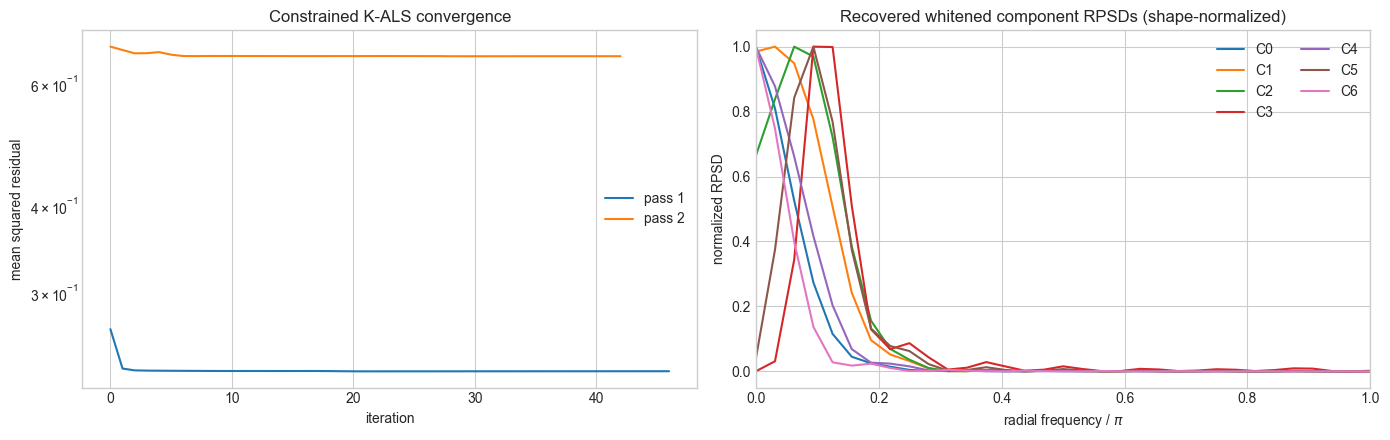

In [8]:
pass2_patches, _, _ = extract_overlapping_patches(
    whitened_roi, PSD_PATCH_SIZE, PSD_STRIDE
)
pass2_rpsds, pass2_variances = estimate_patch_rpsds(pass2_patches)
pass2 = fit_constrained_kals(
    pass2_rpsds,
    K_COMPONENTS,
    restarts=KALS_RESTARTS,
    max_iter=KALS_MAX_ITER,
    tol=KALS_TOL,
    min_relative_improvement=MIN_RELATIVE_IMPROVEMENT,
    seed=RANDOM_SEED + 100,
)
pass2_noise_psd, component_psds, detection_noise_variance, component_signal_variances = (
    variance_calibrate_kals(pass2, pass2_variances)
)

assignment_counts = pd.DataFrame({
    "component": np.arange(K_COMPONENTS),
    "assigned patches": [np.sum(pass2.assignments == k) for k in range(K_COMPONENTS)],
    "calibrated signal variance": component_signal_variances,
})
print("Pass-2 background patches:", int(np.sum(pass2.assignments < 0)))
display(assignment_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].semilogy(pass1.objective_history, label="pass 1")
axes[0].semilogy(pass2.objective_history, label="pass 2")
axes[0].set(title="Constrained K-ALS convergence", xlabel="iteration", ylabel="mean squared residual")
axes[0].legend()
for k in range(K_COMPONENTS):
    curve = component_psds[k]
    axes[1].plot(radial_points / np.pi, curve / max(curve.max(), 1e-12), label=f"C{k}")
axes[1].set(
    title="Recovered whitened component RPSDs (shape-normalized)",
    xlabel=r"radial frequency / $\pi$",
    ylabel="normalized RPSD",
    xlim=(0, 1),
)
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

## Oracle post-hoc component mapping

The assignment below does not alter the fitted spectra. A common spectral
patch is labeled after fitting when a GT center lies inside it. The confusion
matrix counts K-ALS component assignments versus these patch labels, and a
Hungarian assignment finds the one-to-one component/class permutation with
maximum agreement.

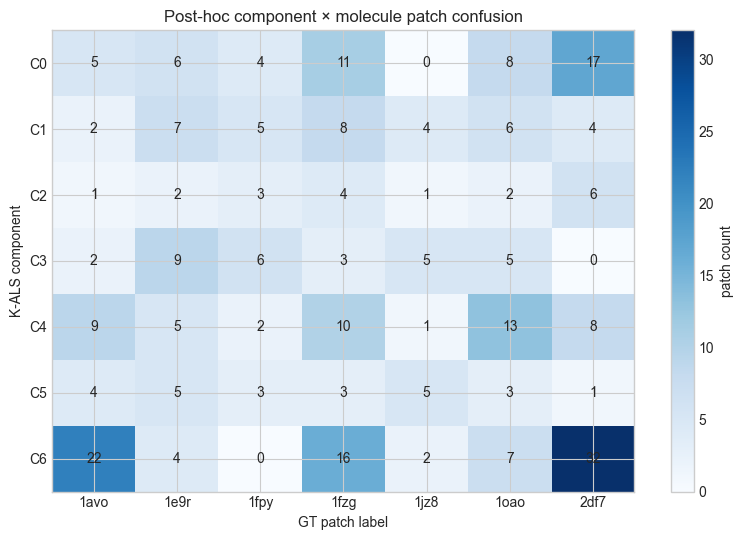

,component,oracle class,diameter D,mapped-label patches,all labeled patches in component,mapping purity
6,6,1avo,18,22,83,0.265060
3,3,1e9r,21,9,30,0.300000
2,2,1fpy,18,3,19,0.157895
1,1,1fzg,28,8,36,0.222222
5,5,1jz8,20,5,24,0.208333
4,4,1oao,20,13,48,0.270833
0,0,2df7,33,17,51,0.333333


In [9]:
confusion = np.zeros((K_COMPONENTS, K_COMPONENTS), dtype=int)
for component in range(K_COMPONENTS):
    for class_index in range(K_COMPONENTS):
        confusion[component, class_index] = np.sum(
            (pass2.assignments == component) & (oracle_patch_labels == class_index)
        )

component_indices, class_indices = linear_sum_assignment(-confusion)
component_to_class = {
    int(component): CLASS_NAMES[int(class_index)]
    for component, class_index in zip(component_indices, class_indices)
}
class_to_component = {label: component for component, label in component_to_class.items()}

mapping_rows = []
for component in range(K_COMPONENTS):
    label = component_to_class[component]
    class_index = CLASS_NAMES.index(label)
    component_labeled = confusion[component].sum()
    mapping_rows.append({
        "component": component,
        "oracle class": label,
        "diameter D": CLASS_DIAMETERS[label],
        "mapped-label patches": confusion[component, class_index],
        "all labeled patches in component": component_labeled,
        "mapping purity": (
            confusion[component, class_index] / component_labeled
            if component_labeled else np.nan
        ),
    })
mapping_table = pd.DataFrame(mapping_rows).sort_values("oracle class")

fig, ax = plt.subplots(figsize=(8, 5.5))
image = ax.imshow(confusion, cmap="Blues", aspect="auto")
for row in range(K_COMPONENTS):
    for column in range(K_COMPONENTS):
        ax.text(column, row, str(confusion[row, column]), ha="center", va="center")
ax.set_xticks(np.arange(K_COMPONENTS), CLASS_NAMES)
ax.set_yticks(np.arange(K_COMPONENTS), [f"C{k}" for k in range(K_COMPONENTS)])
fig.colorbar(image, ax=ax, label="patch count")
ax.set(title="Post-hoc component × molecule patch confusion", xlabel="GT patch label", ylabel="K-ALS component")
plt.tight_layout()
plt.show()
display(mapping_table)

## Fredholm/template/scoring helpers

In [10]:
def geometry_from_diameter(diameter):
    radius = FREDHOLM_RADIUS_RATIO * float(diameter)
    template_side = 2 * int(np.ceil(radius)) + 1
    return radius, template_side, NMS_RADIUS_RATIO * float(diameter)


def build_component_templates(component_psd, diameter):
    radius, template_side, nms_radius = geometry_from_diameter(diameter)
    detector = KLTParticleDetector3D(
        whitened_roi,
        particle_diameter=float(diameter),
        mgscale=1.0,
        num_particles=1,
        legendre_order=LEGENDRE_ORDER,
        threshold=-np.inf,
        max_iter=1,
        max_order=MAX_ANGULAR_ORDER,
        psd_patch_size=PSD_PATCH_SIZE,
        fredholm_radius=radius,
        template_side=template_side,
        bandpass_low_fraction=BANDPASS_LOW_FRACTION,
        bandpass_high_fraction=BANDPASS_HIGH_FRACTION,
        nms_radius=nms_radius,
    )
    nodes, _ = scipy.special.roots_legendre(LEGENDRE_ORDER)
    frequency_nodes = np.pi * (nodes + 1) / 2
    Gx = np.maximum(
        np.asarray(trigonometric_interpolation(radial_points, component_psd, frequency_nodes)),
        0.0,
    )

    eigvals_by_order, eigfuncs_by_order = [], []
    for ell in range(MAX_ANGULAR_ORDER):
        eigvals, eigfuncs, _ = solve_radial_fredholm_equation(
            Gx, ell, radius, np.pi, K=LEGENDRE_ORDER
        )
        eigvals_by_order.append(eigvals)
        eigfuncs_by_order.append(eigfuncs)

    eigvals = np.asarray(eigvals_by_order).reshape(-1)
    eigfuncs = np.asarray(eigfuncs_by_order).transpose(0, 2, 1).reshape(-1, LEGENDRE_ORDER)
    orders = np.repeat(np.arange(MAX_ANGULAR_ORDER), LEGENDRE_ORDER)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigfuncs, orders = eigvals[order], eigfuncs[order], orders[order]
    positive = eigvals > np.spacing(1)
    eigvals, eigfuncs, orders = eigvals[positive], eigfuncs[positive], orders[positive]
    if not len(eigvals):
        raise RuntimeError("Fredholm solver returned no positive modes")
    templates, _ = detector.create_GPSF_templates(eigvals, eigfuncs, orders, Gx)
    return detector, np.asarray(templates)


def score_component(component, diameter):
    detector, templates = build_component_templates(component_psds[component], diameter)
    detector.detect_particles(templates, detection_noise_variance, whitened_roi)
    score = np.asarray(detector.score_mat)
    if score.ndim != 3 or not np.all(np.isfinite(score)):
        raise RuntimeError(f"Invalid score tensor for component {component}, D={diameter}")
    return detector, score


def top_known_count_picks(detector, score, count):
    indices, values = ranked_local_maxima_nms_3d(
        score,
        radius=detector.nms_radius_voxels,
        max_picks=int(count),
    )
    centers = indices.astype(float) + detector.template_side // 2
    return np.column_stack((centers, values))


def match_picks(picks, ground_truth, tolerance):
    if len(picks) == 0 or len(ground_truth) == 0:
        return 0, np.empty(0, dtype=float)
    distances = cdist(picks[:, :3], ground_truth)
    invalid_cost = (max(len(picks), len(ground_truth)) + 1) * (tolerance + 1)
    costs = np.where(distances <= tolerance, distances, invalid_cost)
    pick_indices, gt_indices = linear_sum_assignment(costs)
    assigned = distances[pick_indices, gt_indices]
    valid = assigned <= tolerance
    return int(valid.sum()), assigned[valid]


score_cache = {}


def evaluate_geometry(mode):
    rows = []
    for label in CLASS_NAMES:
        component = class_to_component[label]
        true_diameter = CLASS_DIAMETERS[label]
        template_diameter = true_diameter if mode == "oracle" else SHARED_DIAMETER
        key = (component, template_diameter)
        if key not in score_cache:
            start = time.perf_counter()
            detector, score = score_component(component, template_diameter)
            score_cache[key] = (detector, score, time.perf_counter() - start)
        detector, score, elapsed = score_cache[key]
        ground_truth = supported_gt_by_class[label]
        picks = top_known_count_picks(detector, score, len(ground_truth))
        tolerance = MATCH_TOLERANCE_RATIO * true_diameter
        matched, distances = match_picks(picks, ground_truth, tolerance)
        rows.append({
            "mode": mode,
            "class": label,
            "component": component,
            "true D": true_diameter,
            "template D": template_diameter,
            "Fredholm radius": detector.fredholm_radius_voxels,
            "template side": detector.template_side,
            "NMS radius": detector.nms_radius_voxels,
            "match tolerance": tolerance,
            "known count": len(ground_truth),
            "matched": matched,
            "recall": matched / len(ground_truth) if len(ground_truth) else np.nan,
            "mean match distance": float(distances.mean()) if len(distances) else np.nan,
            "max match distance": float(distances.max()) if len(distances) else np.nan,
            "score max": float(np.max(score)),
            "score seconds": elapsed,
        })
        print(
            f"{mode:6s} {label} <- C{component}, template D={template_diameter:2d}: "
            f"{matched}/{len(ground_truth)} matched"
        )
    return pd.DataFrame(rows)

## Evaluation 1 — oracle class-specific template geometry

After the post-hoc oracle permutation, each component uses its mapped
molecule's diameter to determine Fredholm support, template side, and NMS
radius. This asks whether the recovered spectra can work when the otherwise
unknown geometry is supplied.

oracle 1avo <- C6, template D=18: 0/9 matched


oracle 1e9r <- C3, template D=21: 0/8 matched


oracle 1fpy <- C2, template D=18: 0/3 matched


oracle 1fzg <- C1, template D=28: 0/11 matched


oracle 1jz8 <- C5, template D=20: 0/5 matched


oracle 1oao <- C4, template D=20: 0/7 matched


oracle 2df7 <- C0, template D=33: 6/11 matched


,mode,class,component,true D,template D,Fredholm radius,template side,NMS radius,match tolerance,known count,matched,recall,mean match distance,max match distance,score max,score seconds
0,oracle,1avo,6,18,18,7.2,17,9.0,9.0,9,0,0.000,NaN,NaN,121362.664,5.628
1,oracle,1e9r,3,21,21,8.4,19,10.5,10.5,8,0,0.000,NaN,NaN,126429.945,20.730
2,oracle,1fpy,2,18,18,7.2,17,9.0,9.0,3,0,0.000,NaN,NaN,121158.766,5.012
3,oracle,1fzg,1,28,28,11.2,25,14.0,14.0,11,0,0.000,NaN,NaN,133853.656,11.097
4,oracle,1jz8,5,20,20,8.0,17,10.0,10.0,5,0,0.000,NaN,NaN,122941.875,3.961
5,oracle,1oao,4,20,20,8.0,17,10.0,10.0,7,0,0.000,NaN,NaN,124773.703,5.760
6,oracle,2df7,0,33,33,13.2,29,16.5,16.5,11,6,0.545,2.62,3.186,138422.219,22.670


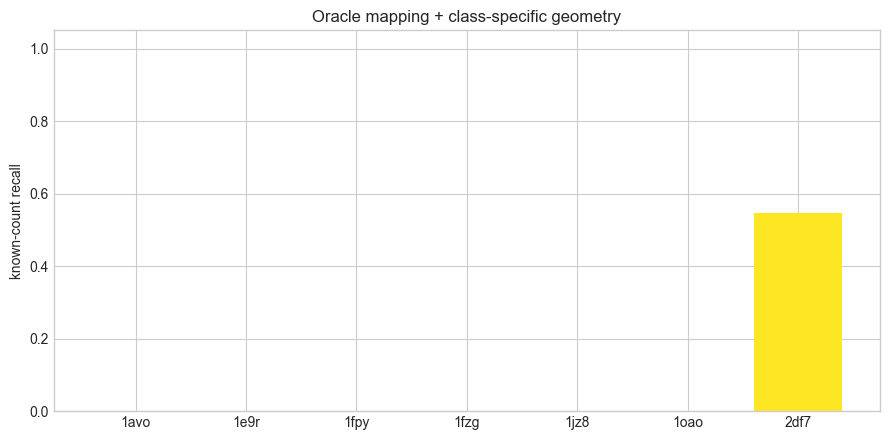

In [11]:
oracle_results = evaluate_geometry("oracle")
display(oracle_results.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = plt.cm.viridis(
    (oracle_results["true D"] - oracle_results["true D"].min())
    / max(oracle_results["true D"].max() - oracle_results["true D"].min(), 1)
)
ax.bar(oracle_results["class"], oracle_results["recall"], color=colors)
ax.set(title="Oracle mapping + class-specific geometry", ylim=(0, 1.05), ylabel="known-count recall")
plt.tight_layout()
plt.show()

## Evaluation 2 — one shared diameter

Every recovered component now uses \(D=33\) for Fredholm support, template
size, and NMS. The oracle permutation is retained only so that anonymous
components can be evaluated against a named simulation class. The matching
tolerance remains \(D_\mathrm{true}/2\), not \(33/2\).

shared 1avo <- C6, template D=33: 0/9 matched


shared 1e9r <- C3, template D=33: 0/8 matched


shared 1fpy <- C2, template D=33: 0/3 matched


shared 1fzg <- C1, template D=33: 0/11 matched


shared 1jz8 <- C5, template D=33: 0/5 matched


shared 1oao <- C4, template D=33: 0/7 matched
shared 2df7 <- C0, template D=33: 6/11 matched


,mode,class,component,true D,template D,Fredholm radius,template side,NMS radius,match tolerance,known count,matched,recall,mean match distance,max match distance,score max,score seconds
0,shared,1avo,6,18,33,13.2,29,16.5,9.0,9,0,0.000,NaN,NaN,138288.297,23.317
1,shared,1e9r,3,21,33,13.2,29,16.5,10.5,8,0,0.000,NaN,NaN,136343.250,18.303
2,shared,1fpy,2,18,33,13.2,29,16.5,9.0,3,0,0.000,NaN,NaN,133736.172,19.343
3,shared,1fzg,1,28,33,13.2,29,16.5,14.0,11,0,0.000,NaN,NaN,134216.672,20.571
4,shared,1jz8,5,20,33,13.2,29,16.5,10.0,5,0,0.000,NaN,NaN,134027.516,11.676
5,shared,1oao,4,20,33,13.2,29,16.5,10.0,7,0,0.000,NaN,NaN,138420.094,22.381
6,shared,2df7,0,33,33,13.2,29,16.5,16.5,11,6,0.545,2.62,3.186,138422.219,22.670


,class,component,true D,known count,oracle matched,oracle recall,template D,shared matched,shared recall,recall change (shared - oracle)
0,1avo,6,18,9,0,0.000,33,0,0.000,0.0
1,1e9r,3,21,8,0,0.000,33,0,0.000,0.0
2,1fpy,2,18,3,0,0.000,33,0,0.000,0.0
3,1fzg,1,28,11,0,0.000,33,0,0.000,0.0
4,1jz8,5,20,5,0,0.000,33,0,0.000,0.0
5,1oao,4,20,7,0,0.000,33,0,0.000,0.0
6,2df7,0,33,11,6,0.545,33,6,0.545,0.0


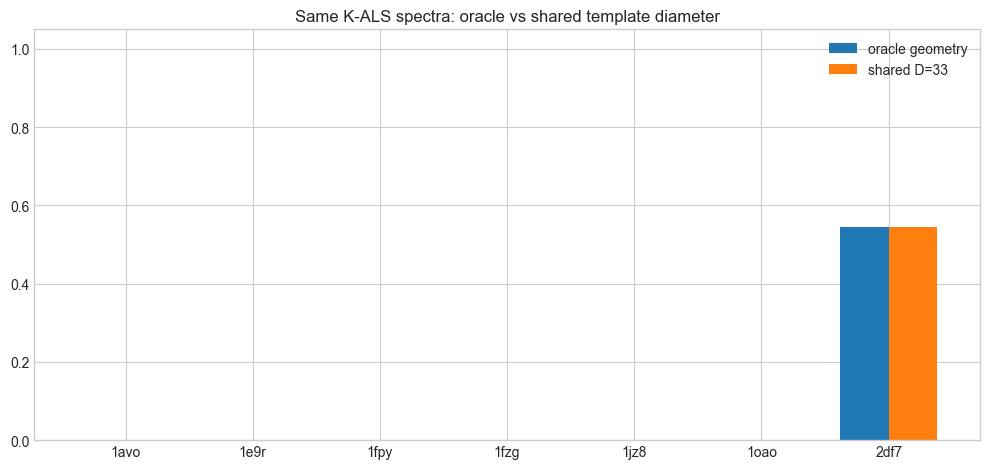

In [12]:
shared_results = evaluate_geometry("shared")
display(shared_results.round(3))

comparison = oracle_results[
    ["class", "component", "true D", "known count", "matched", "recall"]
].rename(columns={"matched": "oracle matched", "recall": "oracle recall"}).merge(
    shared_results[["class", "template D", "matched", "recall"]].rename(
        columns={"matched": "shared matched", "recall": "shared recall"}
    ),
    on="class",
)
comparison["recall change (shared - oracle)"] = (
    comparison["shared recall"] - comparison["oracle recall"]
)
display(comparison.round(3))

plot_data = comparison.melt(
    id_vars=["class"],
    value_vars=["oracle recall", "shared recall"],
    var_name="geometry",
    value_name="recall",
)
fig, ax = plt.subplots(figsize=(10, 4.8))
positions_x = np.arange(len(CLASS_NAMES))
width = 0.38
oracle_values = comparison.set_index("class").loc[CLASS_NAMES, "oracle recall"]
shared_values = comparison.set_index("class").loc[CLASS_NAMES, "shared recall"]
ax.bar(positions_x - width/2, oracle_values, width, label="oracle geometry")
ax.bar(positions_x + width/2, shared_values, width, label="shared D=33")
ax.set_xticks(positions_x, CLASS_NAMES)
ax.set(title="Same K-ALS spectra: oracle vs shared template diameter", ylim=(0, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

## Diagnostic summary

In [13]:
total_oracle = int(oracle_results["matched"].sum())
total_shared = int(shared_results["matched"].sum())
total_gt = int(oracle_results["known count"].sum())
macro_oracle = float(oracle_results["recall"].mean())
macro_shared = float(shared_results["recall"].mean())

summary = pd.Series({
    "total supported GT": total_gt,
    "oracle matched": total_oracle,
    "shared-D matched": total_shared,
    "oracle micro recall": total_oracle / total_gt if total_gt else np.nan,
    "shared-D micro recall": total_shared / total_gt if total_gt else np.nan,
    "oracle macro recall": macro_oracle,
    "shared-D macro recall": macro_shared,
})
display(summary.to_frame("value").round(4))

oracle_detected_classes = oracle_results.loc[
    oracle_results["matched"] > 0, "class"
].tolist()
mapping_purities = mapping_table["mapping purity"].dropna()
if len(oracle_detected_classes) < K_COMPONENTS:
    print(
        "\nObserved result: oracle geometry did not validate seven distinct "
        "molecule components. Classes with at least one oracle match: "
        + (", ".join(oracle_detected_classes) or "none")
        + "."
    )
    print(
        "This points to component-identification failure before diameter "
        "selection: the post-hoc mapping purities range from "
        f"{mapping_purities.min():.3f} to {mapping_purities.max():.3f}."
    )
if np.allclose(
    oracle_results["recall"].fillna(-1),
    shared_results["recall"].fillna(-1),
):
    print(
        "The shared-D and oracle recalls are identical in this run, so "
        "diameter choice is not the limiting factor for these recovered "
        "components."
    )

print(
    "\nInterpretation guardrail: success here establishes feasibility of the "
    "spectral components under an oracle permutation and known class counts. "
    "It does not solve anonymous component naming, diameter estimation, model "
    "selection for K, or unknown-count thresholding in real data."
)

,value
total supported GT,54.0000
oracle matched,6.0000
shared-D matched,6.0000
oracle micro recall,0.1111
shared-D micro recall,0.1111
oracle macro recall,0.0779
shared-D macro recall,0.0779



Observed result: oracle geometry did not validate seven distinct molecule components. Classes with at least one oracle match: 2df7.
This points to component-identification failure before diameter selection: the post-hoc mapping purities range from 0.158 to 0.333.
The shared-D and oracle recalls are identical in this run, so diameter choice is not the limiting factor for these recovered components.

Interpretation guardrail: success here establishes feasibility of the spectral components under an oracle permutation and known class counts. It does not solve anonymous component naming, diameter estimation, model selection for K, or unknown-count thresholding in real data.
